## Week 10 - Assignment 10: Relationships & Modeling

For this assignment, I will be looking at the fetch_california_housing dataset from sklearn.datasets. 

In [1]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from matplotlib.colors import ListedColormap
import statsmodels.api as sm

sns.set_theme()

In [21]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

housing_bunch = fetch_california_housing()

housing = pd.DataFrame(housing_bunch.data, columns=housing_bunch.feature_names)

housing["MedHouseValue"] = housing_bunch.target

housing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Scatterplot

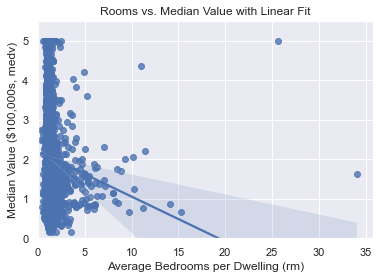

In [24]:
sns.regplot(data=housing, x="AveBedrms", y="MedHouseValue")
plt.title("Rooms vs. Median Value with Linear Fit")
plt.xlabel("Average Bedrooms per Dwelling (rm)")
plt.ylabel("Median Value ($100,000s, medv)")

plt.xlim(left=0)
plt.ylim(bottom=0)

plt.show()

### Correlation Matrix Heatmap

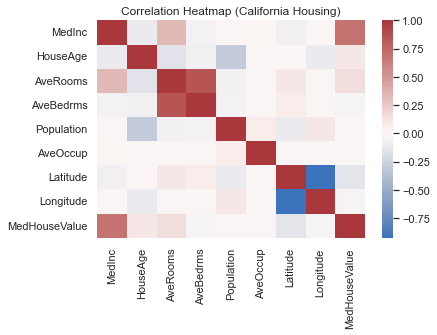

In [9]:
corr = housing.corr(numeric_only=True)
sns.heatmap(corr, annot=False, cmap="vlag", center=0)
plt.title("Correlation Heatmap (California Housing)")
plt.show()

### Residual Plot

In [11]:
X = sm.add_constant(housing["AveBedrms"])
y = housing["MedHouseValue"]
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          MedHouseValue   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     45.11
Date:                Mon, 03 Nov 2025   Prob (F-statistic):           1.91e-11
Time:                        14:47:50   Log-Likelihood:                -32219.
No. Observations:               20640   AIC:                         6.444e+04
Df Residuals:                   20638   BIC:                         6.446e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.1933      0.020    108.431      0.0

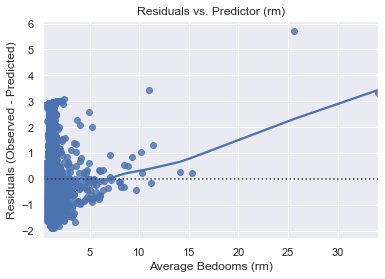

In [12]:
sns.residplot(x=housing["AveBedrms"], y=housing["MedHouseValue"], lowess=True)
plt.title("Residuals vs. Predictor (rm)")
plt.xlabel("Average Bedooms (rm)")
plt.ylabel("Residuals (Observed - Predicted)")
plt.show()

### Reflections: What relationships I observed

When analyzing the scatterplot with the regression line, I observed an unexpected negative relationship between the average number of bedrooms per dwelling and the median house value. Rather than prices increasing with larger homes, the visualization showed that median values tended to be higher when there were fewer average bedrooms. This trend initially seemed counterintuitive, but it may reflect the fact that homes with fewer bedrooms can still be located in more desirable or expensive areas, such as near the coast or in cities, where overall property values are much higher. In contrast, houses with many bedrooms might be more common in suburban or rural regions where prices are lower on average.\
The visualization was helpful in challenging my assumptions about the data. I initially expected a clear positive relationship between house size and price, assuming that more bedrooms would mean higher value. However, the regression line revealed the opposite pattern, encouraging me to think critically about what the “average number of bedrooms” variable really represents. It does not necessarily measure the total size or luxury of a home but rather the ratio of bedrooms to total rooms, which may behave differently. The confidence interval also highlighted variability in the data, suggesting that location and other contextual features play a stronger role than room count alone. This experience showed me how visual analysis can uncover subtle and surprising insights that raw data alone might hide.